In [1]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"


##### import library

In [2]:
import sys
from pathlib import Path

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "utility.py").exists():
            return p
    return start

PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



In [3]:
from sklearn.mixture import GaussianMixture
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import utility
try:
    import pingouin as pg
except ModuleNotFoundError:
    pg = None

from pingouin import compute_effsize


##### Read file

In [4]:
# Load all the three data and concat them to get the final result
import pandas as pd
fabZ = pd.read_csv(str(DATA_DIR / "fabZ_complete_result_kgain.csv"))
lpxC = pd.read_csv(str(DATA_DIR / "lpxC_complete_result_kgain.csv"))
murA = pd.read_csv(str(DATA_DIR / "murA_complete_result_kgain.csv"))# concat them 

final_result = pd.concat([fabZ,lpxC,murA])
final_result.drop(["FullDesignId", "Unnamed: 0"], axis=1, inplace=True)
final_result = final_result.drop_duplicates(subset=['TargetAaPosition', 'MutatedAa',
       'MutatedCodon', 'TargetAa', 'TargetCodon', 'CompetitionCoefficient',
       'fre_flank', 'alt_flank', "accumulated_gain",'GeneName'], keep="first")
final_result['CompetitionCoefficient'] = final_result['CompetitionCoefficient'].str.replace(',', '.').astype(float)
final_result['key'] = final_result['TargetAa'] + final_result['TargetAaPosition'].astype(str) + final_result['MutatedAa'] + final_result['GeneName']
final_result.head()


,GeneName,TargetAaPosition,MutatedAa,MutatedCodon,TargetAa,TargetCodon,CompetitionCoefficient,fre_flank,alt_flank,occurence,log_likelihood_gain,ref_sliding_window,alt_sliding_window,accumulated_gain,key
0,fabZ,4,A,GCG,N,AAC,0.014575,GACTACTAACACTCATA,GACTACTGCGACTCATA,6.0,0.916291,TAACACTCAT,TGCGACTCAT,2.813411,N4AfabZ
8,fabZ,4,C,TGC,N,AAC,-0.012498,GACTACTAACACTCATA,GACTACTTGCACTCATA,6.0,0.693147,TAACACTCAT,TTGCACTCAT,-3.988984,N4CfabZ
16,fabZ,4,D,GAT,N,AAC,-0.118355,GACTACTAACACTCATA,GACTACTGATACTCATA,5.0,1.871802,CTAACACTCA,CTGATACTCA,3.651139,N4DfabZ
24,fabZ,4,E,GAA,N,AAC,-0.612275,GACTACTAACACTCATA,GACTACTGAAACTCATA,5.0,1.704748,CTAACACTCA,CTGAAACTCA,2.860347,N4EfabZ
32,fabZ,4,F,TTT,N,AAC,-0.251570,GACTACTAACACTCATA,GACTACTTTTACTCATA,6.0,2.197225,TAACACTCAT,TTTTACTCAT,2.772589,N4FfabZ


##### import tolerance score

In [5]:
# Sample DataFrame (assuming 'tol' is already loaded)
def categorize_rsa(value):
    if pd.isna(value):  # Handling NaN values
        return np.nan
    if 0 <= value <= 1:
        return "buried"
    if value > 1:
        return "Surface exposed"
    return np.nan


In [6]:
tol = pd.read_csv(str(DATA_DIR / "41467_2023_35940_MOESM8_ESM.csv"))
tol['MutatedAa'] = tol['MutatedAa'].str.split(',')
tol = tol.explode('MutatedAa').reset_index(drop=True)
tol['key'] = tol['TargetAa'] + tol['TargetAaPosition'].astype(str) + tol['MutatedAa'] + tol['GeneName']
tol.head()
# Apply function to create a new column
tol["RSA_Category"] = tol["RSA"].apply(categorize_rsa)



In [7]:
# Make key of col TargetAa TargetAaPosition and mutatedAa for fabZ_ab
# tol['key'] = tol['Residue'] + tol['Allowed substitutions'] + tol['Protein']
tol

,GeneName,TargetAa,TargetAaPosition,ToleranceScore,MutatedAa,RSA,Annotation,key,RSA_Category
0,fabZ,T,2,0.95,A,NaN,NaN,T2AfabZ,NaN
1,fabZ,T,2,0.95,C,NaN,NaN,T2CfabZ,NaN
2,fabZ,T,2,0.95,D,NaN,NaN,T2DfabZ,NaN
3,fabZ,T,2,0.95,E,NaN,NaN,T2EfabZ,NaN
4,fabZ,T,2,0.95,F,NaN,NaN,T2FfabZ,NaN
...,...,...,...,...,...,...,...,...,...
13962,murA,E,419,1.00,S,NaN,NaN,E419SmurA,NaN
13963,murA,E,419,1.00,T,NaN,NaN,E419TmurA,NaN
13964,murA,E,419,1.00,V,NaN,NaN,E419VmurA,NaN
13965,murA,E,419,1.00,W,NaN,NaN,E419WmurA,NaN


##### Generate dataframe with Gene vs kGain and Tolerance score

In [8]:
tmp_gene = final_result.merge(tol.drop(["Annotation"], axis=1).drop_duplicates(), on = ['GeneName', 'TargetAa', 'TargetAaPosition', 
       'MutatedAa', 'key'], how = "left")

In [9]:
tmp_gene.head()

,GeneName,TargetAaPosition,MutatedAa,MutatedCodon,TargetAa,TargetCodon,CompetitionCoefficient,fre_flank,alt_flank,occurence,log_likelihood_gain,ref_sliding_window,alt_sliding_window,accumulated_gain,key,ToleranceScore,RSA,RSA_Category
0,fabZ,4,A,GCG,N,AAC,0.014575,GACTACTAACACTCATA,GACTACTGCGACTCATA,6.0,0.916291,TAACACTCAT,TGCGACTCAT,2.813411,N4AfabZ,1.0,NaN,NaN
1,fabZ,4,C,TGC,N,AAC,-0.012498,GACTACTAACACTCATA,GACTACTTGCACTCATA,6.0,0.693147,TAACACTCAT,TTGCACTCAT,-3.988984,N4CfabZ,1.0,NaN,NaN
2,fabZ,4,D,GAT,N,AAC,-0.118355,GACTACTAACACTCATA,GACTACTGATACTCATA,5.0,1.871802,CTAACACTCA,CTGATACTCA,3.651139,N4DfabZ,1.0,NaN,NaN
3,fabZ,4,E,GAA,N,AAC,-0.612275,GACTACTAACACTCATA,GACTACTGAAACTCATA,5.0,1.704748,CTAACACTCA,CTGAAACTCA,2.860347,N4EfabZ,1.0,NaN,NaN
4,fabZ,4,F,TTT,N,AAC,-0.251570,GACTACTAACACTCATA,GACTACTTTTACTCATA,6.0,2.197225,TAACACTCAT,TTTTACTCAT,2.772589,N4FfabZ,1.0,NaN,NaN


##### Binarize the tolerance category with 1 as tolerance cut off

In [10]:
tmp_gene["tolerance_category"] = pd.Series(pd.NA, index=tmp_gene.index, dtype="object")
valid_mask = tmp_gene["ToleranceScore"].notna()
tmp_gene.loc[valid_mask, "tolerance_category"] = np.where(
    tmp_gene.loc[valid_mask, "ToleranceScore"] >= 1,
    "Tolerant",
    "Intolerant"
)

# tmp_gene["tolerance_category"]  = tmp_gene["ToleranceScore"].apply(lambda x: "Tolerant" if x>=1 else "Intolerant")



In [11]:
tmp_gene = tmp_gene.sort_values(by='tolerance_category', ascending=False)
tmp_gene.reset_index(inplace=True, drop = True)

In [12]:
tmp_gene.head()

,GeneName,TargetAaPosition,MutatedAa,MutatedCodon,TargetAa,TargetCodon,CompetitionCoefficient,fre_flank,alt_flank,occurence,log_likelihood_gain,ref_sliding_window,alt_sliding_window,accumulated_gain,key,ToleranceScore,RSA,RSA_Category,tolerance_category
0,fabZ,4,A,GCG,N,AAC,0.014575,GACTACTAACACTCATA,GACTACTGCGACTCATA,6.0,0.916291,TAACACTCAT,TGCGACTCAT,2.813411,N4AfabZ,1.0,NaN,NaN,Tolerant
1,lpxC,295,P,CCG,L,TTG,-0.190236,ACTGCCGTTGGCCTTCA,ACTGCCGCCGGCCTTCA,7.0,0.810930,TTGGCCTTCA,CCGGCCTTCA,-4.486570,L295PlpxC,1.0,72.05,Surface exposed,Tolerant
2,lpxC,295,H,CAT,L,TTG,-0.210803,ACTGCCGTTGGCCTTCA,ACTGCCGCATGCCTTCA,7.0,0.559616,TTGGCCTTCA,CATGCCTTCA,-6.221760,L295HlpxC,1.0,72.05,Surface exposed,Tolerant
3,lpxC,295,I,ATT,L,TTG,0.078186,ACTGCCGTTGGCCTTCA,ACTGCCGATTGCCTTCA,3.0,1.252763,GCCGTTGGCC,GCCGATTGCC,0.096127,L295IlpxC,1.0,72.05,Surface exposed,Tolerant
4,lpxC,295,K,AAA,L,TTG,-0.168919,ACTGCCGTTGGCCTTCA,ACTGCCGAAAGCCTTCA,5.0,1.011601,CGTTGGCCTT,CGAAAGCCTT,2.165849,L295KlpxC,1.0,72.05,Surface exposed,Tolerant


##### fig S7a. Plot median kGain heatmap and tolerance score heatmap for lpxC

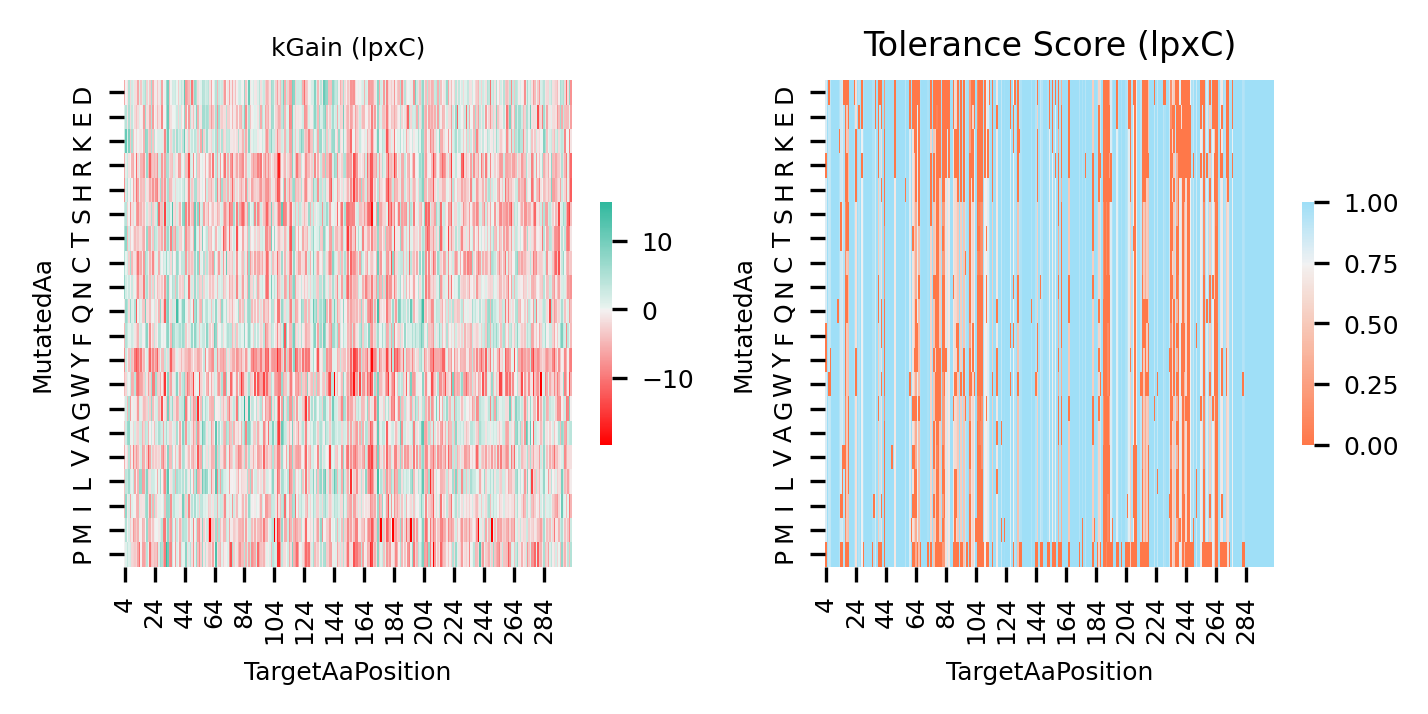

In [13]:
fig_w_mm, fig_h_mm = 120, 60
fig_w_in, fig_h_in = fig_w_mm / 25.4, fig_h_mm / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 6,
    "axes.titlesize": 8,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fig, axes = plt.subplots(1, 2, figsize=(fig_w_in, fig_h_in), dpi=300)

cmap_kgain = sns.diverging_palette(25, 180, l=50, s=400, as_cmap=True)
cmap_tolerance = sns.diverging_palette(20, 240, l=70, s=150, as_cmap=True)

amino_acid_order = ["D", "E", "K", "R", "H", "S", "T", "C", "N", "Q", "F", "Y", "W", "G", "A", "V", "L", "I", "M", "P"]

gene = "lpxC"
df_gene = tmp_gene[tmp_gene["GeneName"] == gene]

df_agg = (
    df_gene.groupby(["MutatedAa", "TargetAaPosition"], as_index=False)
    .agg(
        accumulated_gain=("accumulated_gain", "median"),
        ToleranceScore=("ToleranceScore", "median"),
    )
)

df_agg["MutatedAa"] = pd.Categorical(df_agg["MutatedAa"], categories=amino_acid_order, ordered=True)

heatmap_data_gain = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="accumulated_gain")
heatmap_data_tolerance = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="ToleranceScore")

heatmap_data_gain = heatmap_data_gain.fillna(heatmap_data_gain.min().min())
heatmap_data_tolerance = heatmap_data_tolerance.fillna(heatmap_data_tolerance.min().min())

tolerance_center = heatmap_data_tolerance.stack().mean()

sns.heatmap(
    heatmap_data_gain,
    cmap=cmap_kgain,
    linecolor="gray",
    ax=axes[0],
    cbar_kws={"shrink": 0.5},
    center=0
)
axes[0].set_title(f"kGain ({gene})", fontsize=6)

axes[1] = sns.heatmap(
    heatmap_data_tolerance,
    cmap=cmap_tolerance,
    linecolor="gray",
    ax=axes[1],
    cbar_kws={"shrink": 0.5},
    center=tolerance_center,
)
axes[1].set_title(f"Tolerance Score ({gene})", fontsize=8)

plt.tight_layout()
fig.savefig("supp_fig7_lpxc_heatmaps_50x50mm.pdf", format="pdf", bbox_inches="tight")
plt.show()



##### fig S7b. Plot median kGain heatmap and tolerance score heatmap for fabZ

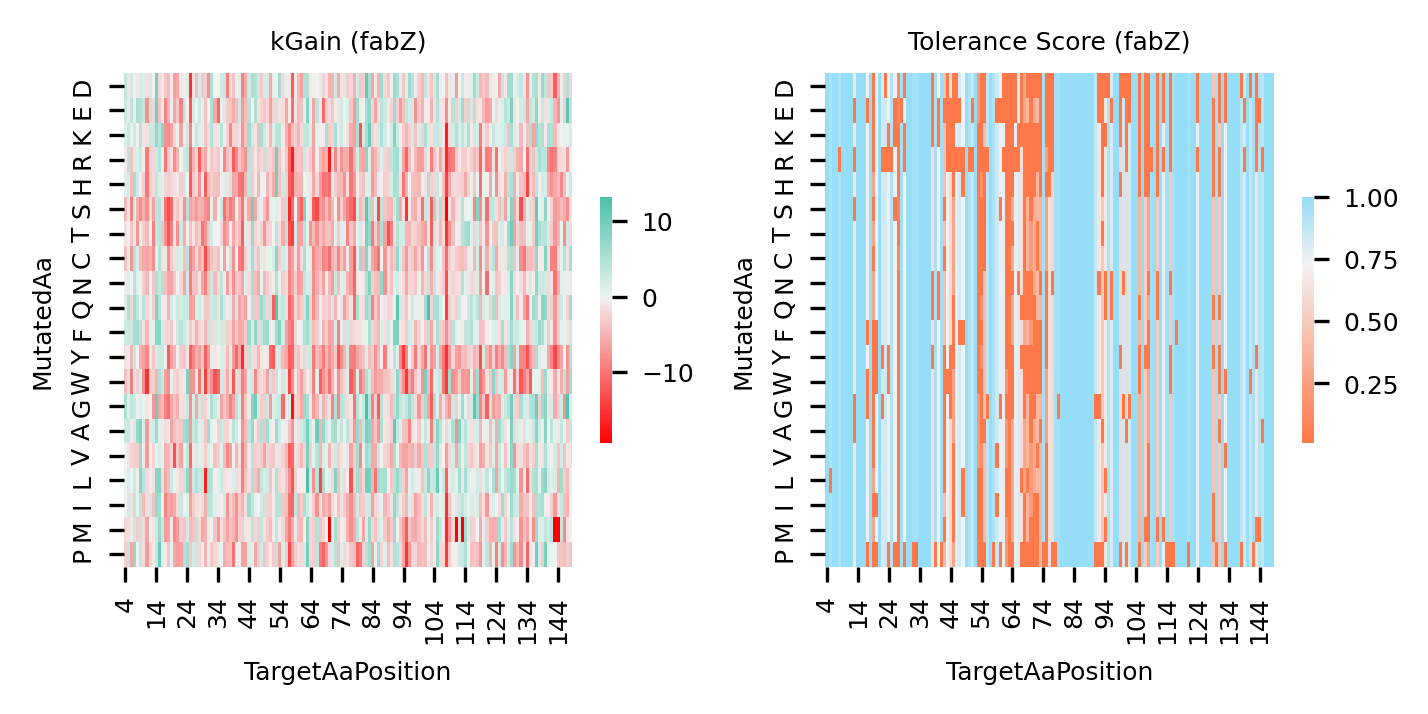

In [14]:
fig_w_mm, fig_h_mm = 120, 60
fig_w_in, fig_h_in = fig_w_mm / 25.4, fig_h_mm / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


fig, axes = plt.subplots(1, 2, figsize=(fig_w_in, fig_h_in), dpi=300)

cmap_kgain = sns.diverging_palette(25, 180, l=50, s=400, as_cmap=True)
cmap_tolerance = sns.diverging_palette(20, 240, l=70, s=150, as_cmap=True)

amino_acid_order = ["D", "E", "K", "R", "H", "S", "T", "C", "N", "Q", "F", "Y", "W", "G", "A", "V", "L", "I", "M", "P"]

gene = "fabZ"
df_gene = tmp_gene[tmp_gene["GeneName"] == gene]

df_agg = (
    df_gene.groupby(["MutatedAa", "TargetAaPosition"], as_index=False)
    .agg(
        accumulated_gain=("accumulated_gain", "median"),
        ToleranceScore=("ToleranceScore", "median"),
    )
)

df_agg["MutatedAa"] = pd.Categorical(df_agg["MutatedAa"], categories=amino_acid_order, ordered=True)

heatmap_data_gain = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="accumulated_gain")
heatmap_data_tolerance = df_agg.pivot(index="MutatedAa", columns="TargetAaPosition", values="ToleranceScore")

heatmap_data_gain = heatmap_data_gain.fillna(heatmap_data_gain.min().min())
heatmap_data_tolerance = heatmap_data_tolerance.fillna(heatmap_data_tolerance.min().min())

tolerance_center = heatmap_data_tolerance.stack().mean()

sns.heatmap(
    heatmap_data_gain,
    cmap=cmap_kgain,
    linecolor="gray",
    ax=axes[0],
    cbar_kws={"shrink": 0.5},
    center=0
)
axes[0].set_title(f"kGain ({gene})", fontsize=6)

axes[1] = sns.heatmap(
    heatmap_data_tolerance,
    cmap=cmap_tolerance,
    linecolor="gray",
    ax=axes[1],
    cbar_kws={"shrink": 0.5},
    center=tolerance_center,
)
axes[1].set_title(f"Tolerance Score ({gene})", fontsize=6)

plt.tight_layout()
fig.savefig("supp_fig7_fabz_heatmaps_50x50mm.pdf", format="pdf", bbox_inches="tight")
plt.show()



##### fig S7 c, d, e: kGain vs tolerance category

,GeneName,p_raw,d,cohend,ci_low,ci_high,p_adj
0,fabZ,0.000041,0.292048,0.158152,0.130742,0.432504,0.000123
1,lpxC,0.192703,0.021662,0.023232,-0.075430,0.122140,0.192703
2,murA,0.005434,0.123284,0.070985,0.042943,0.222731,0.008152


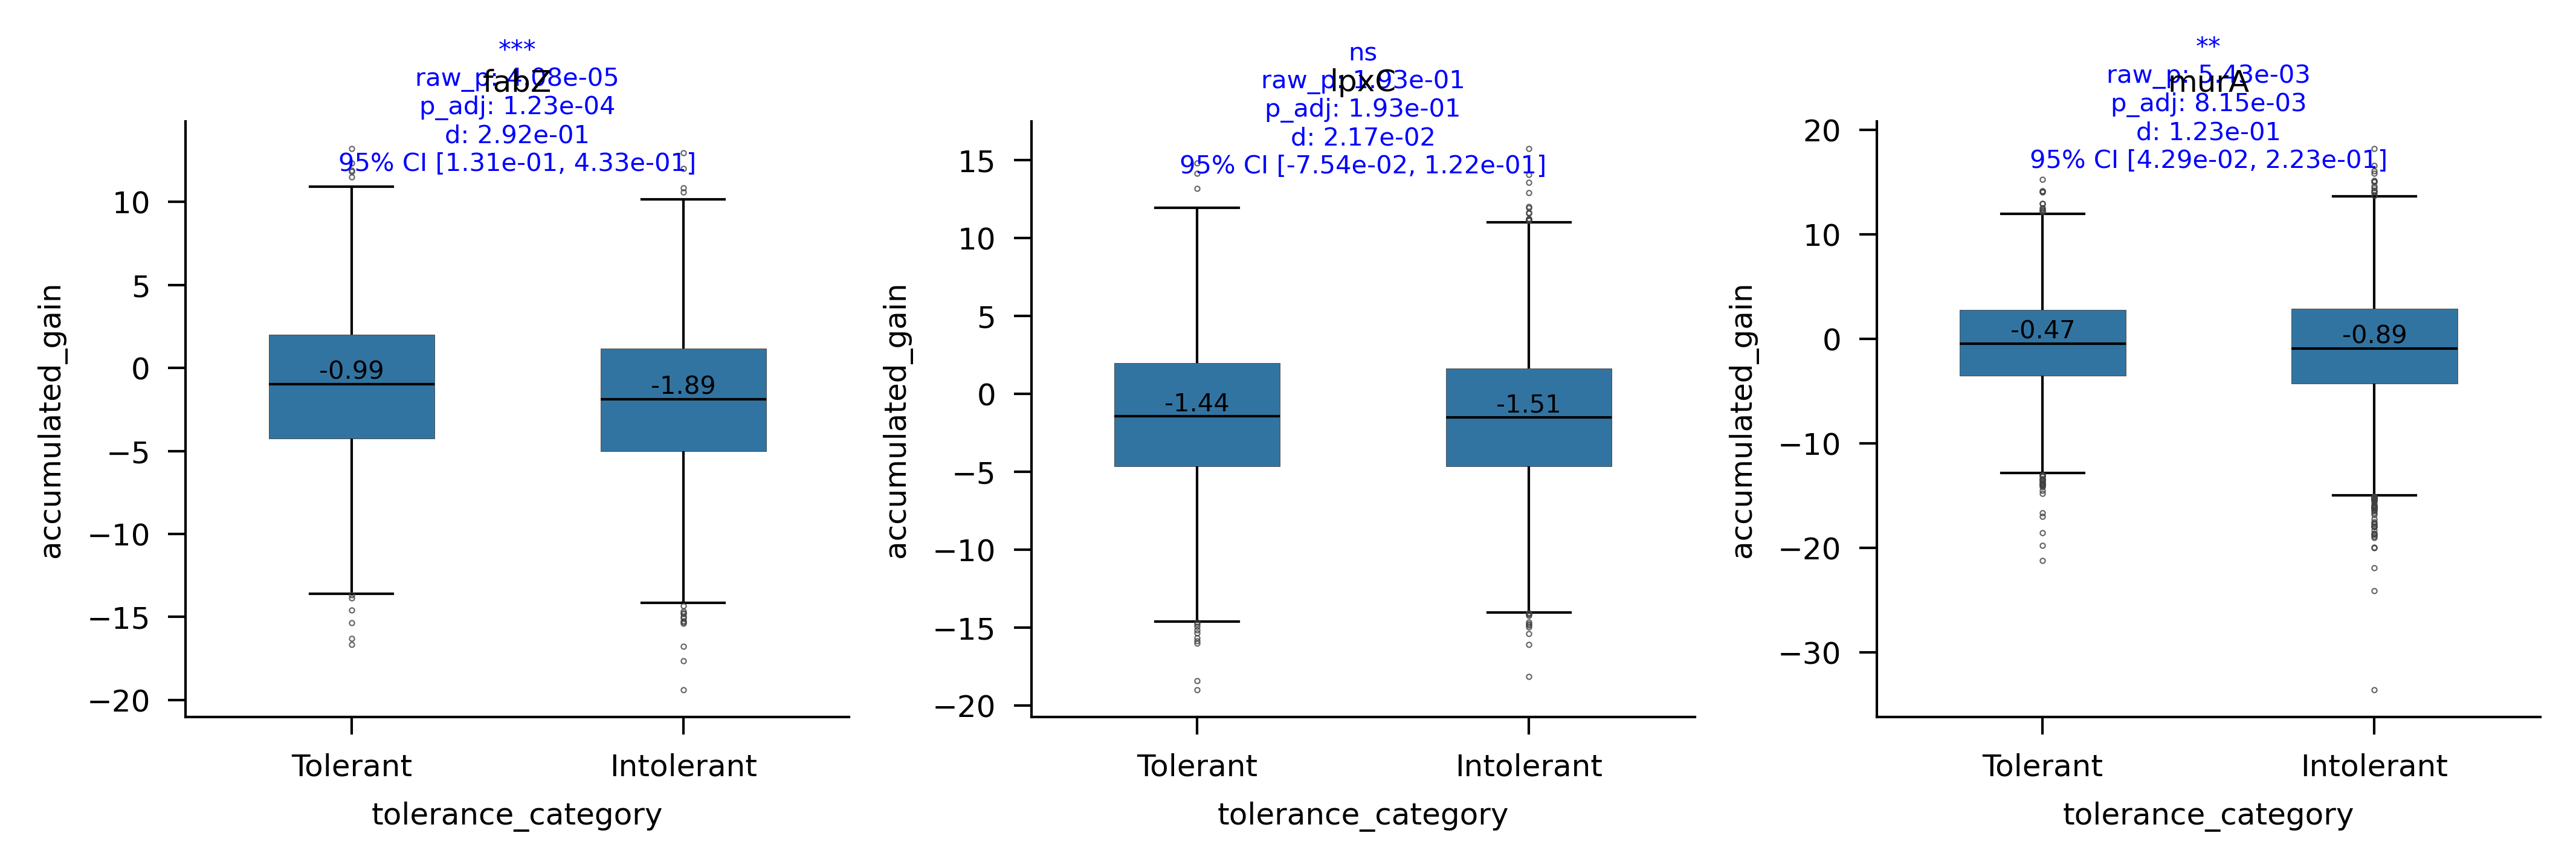

In [15]:
from statsmodels.stats.multitest import multipletests

fig_w_mm, fig_h_mm = 180, 60
fig_w_in, fig_h_in = fig_w_mm / 25.4, fig_h_mm / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

gene_order = sorted(tmp_gene["GeneName"].dropna().unique())
fig, axes = plt.subplots(1, len(gene_order), figsize=(fig_w_in, fig_h_in), dpi=600)
if len(gene_order) == 1:
    axes = [axes]

stats_rows = []
for gene_name in gene_order:
    tmp = tmp_gene[tmp_gene["GeneName"] == gene_name].copy()
    tmp = tmp[tmp["tolerance_category"].isin(["Tolerant", "Intolerant"])].copy()

    g1 = tmp[tmp["tolerance_category"] == "Tolerant"]["accumulated_gain"].dropna()
    g2 = tmp[tmp["tolerance_category"] == "Intolerant"]["accumulated_gain"].dropna()

    if len(g1) == 0 or len(g2) == 0:
        p_raw = np.nan
        d_value, ci_low, ci_high = np.nan, np.nan, np.nan
        cohend = np.nan
    else:
        p_raw = utility.man_whiteney(g1, g2, alternative="greater")
        d_value, ci_low, ci_high = utility.median_based_distance_ci(g1, g2)
        cohend = pg.compute_effsize(g1, g2, eftype='cohen') if (len(g1) >= 2 and len(g2) >= 2) else np.nan

    stats_rows.append(
        {
            "GeneName": gene_name,
            "p_raw": p_raw,
            "d": d_value,
            "cohend": cohend,
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

stats_df = pd.DataFrame(stats_rows)
stats_df["p_adj"] = np.nan
valid_idx = stats_df["p_raw"].notna()
if valid_idx.any():
    _, p_adj, _, _ = multipletests(stats_df.loc[valid_idx, "p_raw"].values, method="fdr_bh")
    stats_df.loc[valid_idx, "p_adj"] = p_adj

for c, gene_name in enumerate(gene_order):
    tmp = tmp_gene[tmp_gene["GeneName"] == gene_name].copy()
    tmp = tmp[tmp["tolerance_category"].isin(["Tolerant", "Intolerant"])].copy()

    axes[c].set_title(gene_name, fontsize=6)
    axes[c] = sns.boxplot(
        data=tmp,
        x='tolerance_category',
        y='accumulated_gain',
        ax=axes[c],
        linewidth=0.1,
        whiskerprops=dict(color="black", linewidth=0.5),
        capprops=dict(color="black", linewidth=0.5),
        medianprops=dict(color="black", linewidth=0.5),
        flierprops=dict(marker="o", color="black", markersize=0.25, alpha=0.8),
        dodge=True,
        width=0.5
    )

    medians = tmp.groupby("tolerance_category")["accumulated_gain"].median()
    for idx, category in enumerate(["Tolerant", "Intolerant"]):
        if category in medians.index:
            axes[c].text(
                idx,
                medians[category],
                f'{medians[category]:.2f}',
                ha='center',
                va='bottom',
                fontsize=5,
                color="black",
            )

    res = stats_df[stats_df["GeneName"] == gene_name].iloc[0]
    p_adj_for_star = res["p_adj"] if pd.notna(res["p_adj"]) else 1.0
    star = utility.get_significance_star(p_adj_for_star)

    y_pos = tmp["accumulated_gain"].max() * 0.9 if not tmp.empty else 0
    raw_txt = f"{res['p_raw']:.2e}" if pd.notna(res['p_raw']) else "NA"
    adj_txt = f"{res['p_adj']:.2e}" if pd.notna(res['p_adj']) else "NA"
    d_txt = f"{res['d']:.2e}" if pd.notna(res['d']) else "NA"
    ci_low_txt = f"{res['ci_low']:.2e}" if pd.notna(res['ci_low']) else "NA"
    ci_high_txt = f"{res['ci_high']:.2e}" if pd.notna(res['ci_high']) else "NA"

    axes[c].text(
        0.5,
        y_pos,
        f"{star}\nraw_p: {raw_txt}\np_adj: {adj_txt}\nd: {d_txt}\n95% CI [{ci_low_txt}, {ci_high_txt}]",
        ha='center',
        fontsize=5,
        color='blue',
    )

    axes[c] = utility.custom_figure_axis(axes[c], fontsize=6, show_ticks=True, rotation=0)

plt.tight_layout()
fig.savefig("supp_fig7_tolerance_boxplots_50x50mm.pdf", format="pdf", bbox_inches="tight")
stats_df



##### fig S5f: kGain vs Gene with RSA as hue

Label=fabZ, p_raw=1.79e-02, p_reported=2.68e-02, effect size=1.03e-01, 95% CI [-3.93e-02, 3.68e-01]
Label=lpxC, p_raw=2.22e-01, p_reported=2.22e-01, effect size=4.75e-02, 95% CI [-7.04e-02, 2.02e-01]
Label=murA, p_raw=1.87e-05, p_reported=5.62e-05, effect size=1.62e-01, 95% CI [4.74e-02, 2.84e-01]


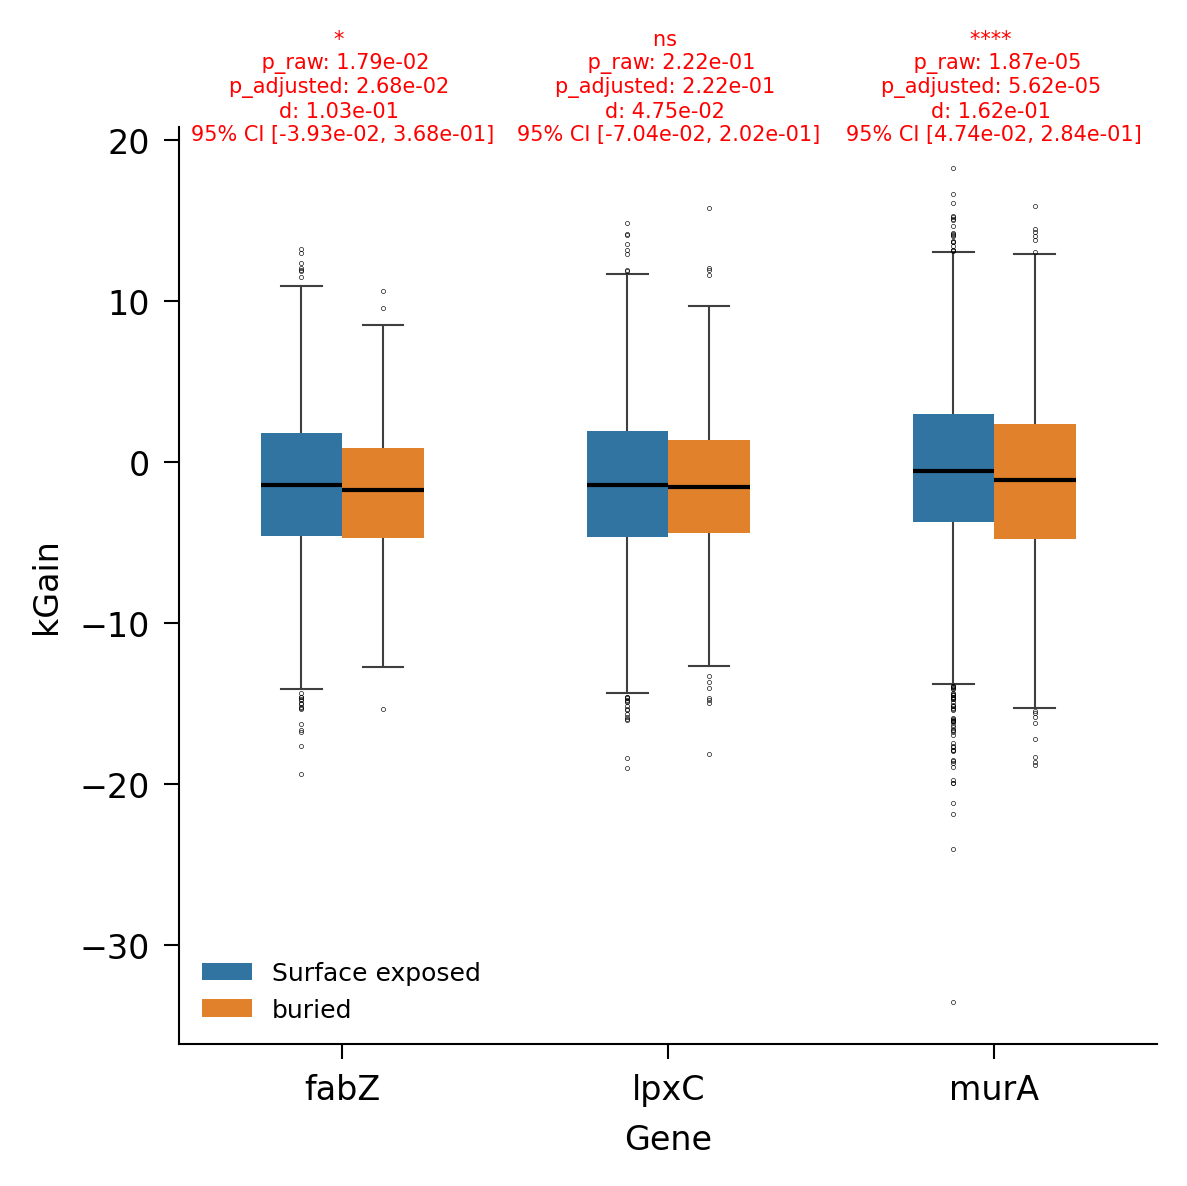

In [16]:
fig_w_mm, fig_h_mm = 100, 100
fig_w_in, fig_h_in = fig_w_mm / 25.4, fig_h_mm / 25.4

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
    "font.size": 6,
    "axes.titlesize": 6,
    "axes.labelsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.facecolor": "white",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(1, 1, figsize=(fig_w_in, fig_h_in), dpi=300)

ax = sns.boxplot(data = tmp_gene, ax=ax, x ='GeneName', hue = 'RSA_Category', y = 'accumulated_gain', boxprops=dict(edgecolor="black", linewidth=0),flierprops=dict(marker='o', markeredgecolor='black'), width=0.5,linewidth=0.5, fliersize=0.15, dodge=True, medianprops={"color": "black","linewidth":1} )
ax = utility.custom_figure_axis(ax=ax, fontsize=8, rotation = 0)
ax.legend(fontsize = 8, ncol=2, frameon=False)
ax.set_ylabel("kGain")
ax.set_xlabel("Gene")

ax = utility.return_box_with_p_effect_size(ax=ax, data = tmp_gene, x_columns = 'GeneName',hue_columns = 'RSA_Category', y_columns ='accumulated_gain', group1_name = "Surface exposed", group2_name = "buried", y_pos= 20, fontsize = 5, p_adjust_method="fdr_bh")
ax.legend(ncol=1, frameon=False)
plt.tight_layout()
fig.savefig("supp_fig7_rsa_boxplot_50x50mm.pdf", format="pdf", bbox_inches="tight")

